# Power Analysis for Paired Cookie Experiment (Toaster vs General Oven)
Goal: determine the required number of cookie *pairs* for a paired t-test
across a few plausible effect sizes (Cohen's d_z) and desired power levels.

Assumptions:
- Test type: two-sided paired t-test (one-sample on paired differences)
- Alpha: 0.05
- Primary outcome (DV): Spread Ratio (or Diameter) difference per pair
- Effect size d_z to explore: 0.4 (small–medium), 0.5 (medium), 0.6 (medium+)


In [1]:
# If statsmodels is not installed:
# %pip install statsmodels pandas numpy

import math
import numpy as np
import pandas as pd
from statsmodels.stats.power import TTestPower


In [2]:
alpha = 0.05                      # two-sided
effect_sizes = [0.4, 0.5, 0.6]    # Cohen's d_z to explore
powers = [0.80, 0.90]             # desired power levels

tt = TTestPower()  # paired t-test == one-sample t-test on paired differences

rows = []
for d in effect_sizes:
    for power in powers:
        n_exact = tt.solve_power(effect_size=d, alpha=alpha, power=power, alternative='two-sided')
        n_pairs = math.ceil(n_exact)  # round up to whole pairs
        rows.append({
            "effect_size_dz": d,
            "power": power,
            "alpha": alpha,
            "required_pairs_exact": n_exact,
            "required_pairs_ceil": n_pairs
        })

df = pd.DataFrame(rows)
df


,effect_size_dz,power,alpha,required_pairs_exact,required_pairs_ceil
0,0.4,0.8,0.05,51.009448,52
1,0.4,0.9,0.05,67.621394,68
2,0.5,0.8,0.05,33.367131,34
3,0.5,0.9,0.05,43.995481,44
4,0.6,0.8,0.05,23.794514,24
5,0.6,0.9,0.05,31.171683,32


In [3]:
expected_exclusion_rate = 0.10  # e.g., expect ~10% pairs might be excluded
df["planning_pairs_with_10pct_buffer"] = np.ceil(df["required_pairs_ceil"] / (1 - expected_exclusion_rate)).astype(int)
df


,effect_size_dz,power,alpha,required_pairs_exact,required_pairs_ceil,planning_pairs_with_10pct_buffer
0,0.4,0.8,0.05,51.009448,52,58
1,0.4,0.9,0.05,67.621394,68,76
2,0.5,0.8,0.05,33.367131,34,38
3,0.5,0.9,0.05,43.995481,44,49
4,0.6,0.8,0.05,23.794514,24,27
5,0.6,0.9,0.05,31.171683,32,36


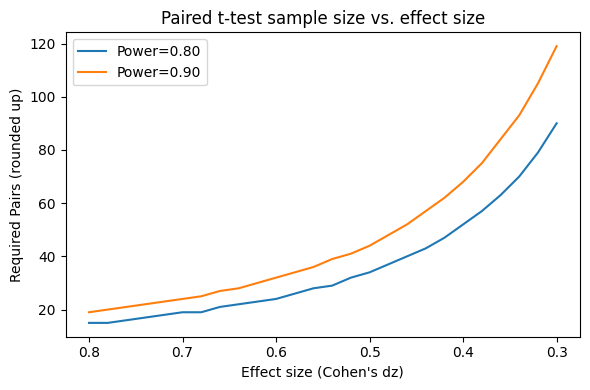

In [4]:
import matplotlib.pyplot as plt

d_grid = np.linspace(0.3, 0.8, 26)  # explore a range of effect sizes
req_pairs_80 = [math.ceil(tt.solve_power(effect_size=d, alpha=alpha, power=0.80, alternative='two-sided')) for d in d_grid]
req_pairs_90 = [math.ceil(tt.solve_power(effect_size=d, alpha=alpha, power=0.90, alternative='two-sided')) for d in d_grid]

plt.figure(figsize=(6,4))
plt.plot(d_grid, req_pairs_80, label='Power=0.80')
plt.plot(d_grid, req_pairs_90, label='Power=0.90')
plt.gca().invert_xaxis()  # larger d -> fewer pairs; invert for readability
plt.xlabel("Effect size (Cohen's dz)")
plt.ylabel("Required Pairs (rounded up)")
plt.title("Paired t-test sample size vs. effect size")
plt.legend()
plt.tight_layout()
plt.show()


**Interim takeaway (no pilot):**
- If we plan for a medium effect (d_z = 0.5) at alpha=0.05, power=0.80,
  we need about **~34 pairs** (i.e., 68 cookies total).
- With a 10% exclusion buffer, plan **~38 pairs**.

We can refine this after a small pilot (6–10 pairs) to estimate the SD of paired differences
and recompute d_z and required pairs more precisely.


In [5]:
# Placeholder for tomorrow (pilot-based):
# Suppose you compute paired differences for the primary DV (e.g., spread ratio):
# diffs = np.array([...])  # toaster - general for pilot
# mean_diff = diffs.mean()
# sd_diff = diffs.std(ddof=1)
# d_z = abs(mean_diff) / sd_diff
# n_exact = tt.solve_power(effect_size=d_z, alpha=0.05, power=0.80, alternative='two-sided')
# math.ceil(n_exact)


In [7]:
out_path = "../results/power_plan_no_pilot.csv"
df.to_csv(out_path, index=False)
out_path


'../results/power_plan_no_pilot.csv'